In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# ĐƯỜNG DẪN
# ============================================================
SPLIT_DIR    = Path("../data/processed/02_split")       # khảo sát thật (train)
SYNTH_DIR    = Path("../data/processed/04_synthetic")   # output GA
OUTPUT_DIR   = Path("../data/processed/05_final")       # output giai đoạn này
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Mapping mã ngành → tên (đầy đủ 39 ngành)
MA_TO_TEN = {
    7810103: "Quản trị dịch vụ du lịch và lữ hành", 7810201: "Quản trị khách sạn",
    7810202: "Quản trị nhà hàng và dịch vụ ăn uống", 7819009: "Khoa học dinh dưỡng và ẩm thực",
    7819010: "Khoa học chế biến món ăn", 7810101: "Du lịch", 7380101: "Luật",
    7380107: "Luật kinh tế", 7220201: "Ngôn ngữ Anh", 7220204: "Ngôn ngữ Trung Quốc",
    7480201: "Công nghệ thông tin", 7480202: "An toàn thông tin", 7460108: "Khoa học dữ liệu",
    7340301: "Kế toán", 7340201: "Tài chính ngân hàng", 7340205: "Công nghệ tài chính",
    7340115: "Marketing", 7340122: "Thương mại điện tử",
    7510605: "Logistics và quản lý chuỗi cung ứng", 7340101: "Quản trị kinh doanh",
    7340120: "Kinh doanh quốc tế", 7540204: "Công nghệ dệt, may",
    7340123: "Kinh doanh thời trang và dệt may", 7540101: "Công nghệ thực phẩm",
    7540106: "Đảm bảo chất lượng và an toàn thực phẩm", 7340129: "Quản trị kinh doanh thực phẩm",
    7540105: "Công nghệ chế biến thủy sản", 7510202: "Công nghệ chế tạo máy",
    7510203: "Công nghệ kỹ thuật cơ điện tử", 7520115: "Kỹ thuật nhiệt",
    7510301: "Công nghệ kỹ thuật điện - điện tử",
    7510303: "Công nghệ kỹ thuật điều khiển và TĐH", 7510401: "Công nghệ kỹ thuật hóa học",
    7510402: "Công nghệ vật liệu", 7420201: "Công nghệ sinh học",
    7850101: "Quản lý tài nguyên và môi trường", 7510406: "Công nghệ kỹ thuật môi trường",
    7480107: "Trí tuệ nhân tạo", 7510601: "Quản lý Công nghiệp",
}
TEN_TO_MA = {v: k for k, v in MA_TO_TEN.items()}

# Cột Likert và điểm thi — thứ tự cố định
LIKERT_COLS = [
    "likert_nang_dong", "likert_huong_noi", "likert_sang_tao", "likert_logic",
    "likert_to_mo", "likert_thi_nghiem", "likert_moi_truong",
    "likert_dinh_duong", "likert_tranh_luan", "likert_thiet_ke",
]
DIEM_COLS = [
    "diem_Toan", "diem_Ly", "diem_Hoa", "diem_Anh", "diem_Van",
    "diem_Su", "diem_Sinh", "diem_Dia", "diem_Gdktpl", "diem_Tin",
]
# Cột output cuối cùng — thứ tự rõ ràng
FINAL_COLS = (
    ["ma_nganh", "nganh_hoc", "to_hop_thi", "gioi_tinh"]
    + LIKERT_COLS
    + DIEM_COLS
    + ["muc_tieu_ma", "muc_tieu_nhan", "nguon_du_lieu", "sample_weight"]
)

print("✅ Config OK")
print(f"   Tổng cột đầu ra: {len(FINAL_COLS)}")


✅ Config OK
   Tổng cột đầu ra: 28


In [10]:
# ============================================================
# NHÓM 1 — Khảo sát thật (sample_weight = 10)
# ============================================================
df_khaosat = pd.read_csv(SPLIT_DIR / "khaosat_train.csv")

# Thêm cột thiếu
df_khaosat["ma_nganh"]      = df_khaosat["nganh_hoc"].map(TEN_TO_MA)
df_khaosat["nguon_du_lieu"] = "khaosat_that"
df_khaosat["sample_weight"] = 10       # ← Độ tin cậy cao nhất

# Chuẩn hóa về FINAL_COLS (chỉ giữ cột cần, bổ sung NaN nếu thiếu)
for col in FINAL_COLS:
    if col not in df_khaosat.columns:
        df_khaosat[col] = np.nan
df_khaosat = df_khaosat[FINAL_COLS].copy()

print(f"Nhóm 1 — Khảo sát thật: {len(df_khaosat):,} dòng  |  sample_weight=10")
print(f"  Số ngành: {df_khaosat['ma_nganh'].nunique()}")
print(f"  Null ma_nganh: {df_khaosat['ma_nganh'].isna().sum()} dòng")


Nhóm 1 — Khảo sát thật: 651 dòng  |  sample_weight=10
  Số ngành: 39
  Null ma_nganh: 0 dòng


In [11]:
# ============================================================
# NHÓM 2 — TTTH thật + GA sinh 12 cột (sample_weight = 1)
# ============================================================
df_ttth = pd.read_csv(SYNTH_DIR / "ttth_day_du_12cot.csv")

# Thêm nganh_hoc từ ma_nganh
df_ttth["nganh_hoc"] = df_ttth["ma_nganh"].map(MA_TO_TEN)

for col in FINAL_COLS:
    if col not in df_ttth.columns:
        df_ttth[col] = np.nan
df_ttth = df_ttth[FINAL_COLS].copy()

print(f"Nhóm 2 — TTTH + GA 12 cột: {len(df_ttth):,} dòng  |  sample_weight=1")
print(f"  Số ngành: {df_ttth['ma_nganh'].nunique()}")


Nhóm 2 — TTTH + GA 12 cột: 15,888 dòng  |  sample_weight=1
  Số ngành: 34


In [12]:
# ============================================================
# NHÓM 3 — GA cân bằng lớp (sample_weight = 1)
# ============================================================
df_canbang = pd.read_csv(SYNTH_DIR / "ga_can_bang_lop.csv")

# ma_nganh đã có, bổ sung nganh_hoc nếu thiếu
if "nganh_hoc" not in df_canbang.columns or df_canbang["nganh_hoc"].isna().all():
    df_canbang["nganh_hoc"] = df_canbang["ma_nganh"].map(MA_TO_TEN)
else:
    df_canbang["nganh_hoc"] = df_canbang["nganh_hoc"].fillna(
        df_canbang["ma_nganh"].map(MA_TO_TEN)
    )

for col in FINAL_COLS:
    if col not in df_canbang.columns:
        df_canbang[col] = np.nan
df_canbang = df_canbang[FINAL_COLS].copy()

print(f"Nhóm 3 — GA cân bằng lớp: {len(df_canbang):,} dòng  |  sample_weight=1")
print(f"  Số ngành: {df_canbang['ma_nganh'].nunique()}")


Nhóm 3 — GA cân bằng lớp: 436 dòng  |  sample_weight=1
  Số ngành: 7


In [13]:
# ============================================================
# GỘP — Stack 3 nhóm, kiểm tra tổng thể
# ============================================================
df_train_final = pd.concat([df_khaosat, df_ttth, df_canbang], ignore_index=True)

# Ép kiểu Likert về int (đã là số nguyên 1-5, có thể bị float sau concat)
for col in LIKERT_COLS:
    df_train_final[col] = pd.to_numeric(df_train_final[col], errors="coerce").round().astype("Int64")

# Ép kiểu điểm thi về float
for col in DIEM_COLS:
    df_train_final[col] = pd.to_numeric(df_train_final[col], errors="coerce")

# Ép kiểu mã ngành về int
df_train_final["ma_nganh"]      = pd.to_numeric(df_train_final["ma_nganh"],      errors="coerce").astype("Int64")
df_train_final["muc_tieu_ma"]   = pd.to_numeric(df_train_final["muc_tieu_ma"],   errors="coerce").astype("Int64")
df_train_final["sample_weight"] = pd.to_numeric(df_train_final["sample_weight"], errors="coerce").astype(int)

print("=== TỔNG HỢP SAU GỘP ===\n")
print(f"Tổng dòng : {len(df_train_final):,}")
print(f"Tổng cột  : {len(df_train_final.columns)}")
print(f"Số ngành  : {df_train_final['ma_nganh'].nunique()} / 39")
print()

# Phân tích theo nguồn
print("Phân bổ theo nguồn dữ liệu:")
summary = df_train_final.groupby("nguon_du_lieu").agg(
    so_dong=("ma_nganh", "count"),
    sample_weight=("sample_weight", "first"),
    so_nganh=("ma_nganh", "nunique")
).reset_index()
print(summary.to_string(index=False))

print()
print("Phân bổ dòng theo ngành:")
dist = df_train_final.groupby(["ma_nganh", "nganh_hoc"])["nguon_du_lieu"].count().reset_index()
dist.columns = ["ma_nganh", "nganh_hoc", "tong_dong"]
dist = dist.sort_values("tong_dong", ascending=False)
print(dist.to_string(index=False))


=== TỔNG HỢP SAU GỘP ===

Tổng dòng : 16,975
Tổng cột  : 28
Số ngành  : 39 / 39

Phân bổ theo nguồn dữ liệu:
  nguon_du_lieu  so_dong  sample_weight  so_nganh
ga_can_bang_lop      436              1         7
   khaosat_that      651             10        39
   ttth_bo_sung    15888              1        34

Phân bổ dòng theo ngành:
 ma_nganh                               nganh_hoc  tong_dong
  7480201                     Công nghệ thông tin       1909
  7340101                     Quản trị kinh doanh       1031
  7540101                     Công nghệ thực phẩm        990
  7340201                     Tài chính ngân hàng        929
  7340120                      Kinh doanh quốc tế        877
  7340115                               Marketing        859
  7340301                                 Kế toán        854
  7380107                            Luật kinh tế        829
  7510303    Công nghệ kỹ thuật điều khiển và TĐH        644
  7480202                       An toàn thông tin      

In [14]:
# ============================================================
# KIỂM TRA CHẤT LƯỢNG
# ============================================================
print("=== KIỂM TRA CHẤT LƯỢNG ===\n")

# 1. Null ở cột không được phép null
print("1. Null ở cột thiết yếu:")
must_not_null = ["ma_nganh", "nganh_hoc", "to_hop_thi", "gioi_tinh",
                 "muc_tieu_ma", "muc_tieu_nhan", "nguon_du_lieu", "sample_weight"]
for col in must_not_null:
    n = df_train_final[col].isna().sum()
    icon = "✅" if n == 0 else "⚠️ "
    print(f"  {icon} {col}: {n} null")

print()
print("2. Null ở Likert (không được phép null):")
for col in LIKERT_COLS:
    n = df_train_final[col].isna().sum()
    icon = "✅" if n == 0 else "❌"
    print(f"  {icon} {col}: {n} null")

print()
print("3. Phân phối Likert (kiểm tra giá trị nằm trong [1,5]):")
for col in LIKERT_COLS:
    vals = df_train_final[col].dropna()
    out_of_range = ((vals < 1) | (vals > 5)).sum()
    icon = "✅" if out_of_range == 0 else "❌"
    print(f"  {icon} {col}: min={vals.min()}, max={vals.max()}, out_of_range={out_of_range}")

print()
print("4. Kiểm tra sample_weight:")
print(f"  {df_train_final.groupby('nguon_du_lieu')['sample_weight'].first().to_dict()}")

print()
print("5. Phân phối mục tiêu nhãn:")
print(df_train_final["muc_tieu_nhan"].value_counts().to_string())


=== KIỂM TRA CHẤT LƯỢNG ===

1. Null ở cột thiết yếu:
  ✅ ma_nganh: 0 null
  ✅ nganh_hoc: 0 null
  ✅ to_hop_thi: 0 null
  ✅ gioi_tinh: 0 null
  ✅ muc_tieu_ma: 0 null
  ✅ muc_tieu_nhan: 0 null
  ✅ nguon_du_lieu: 0 null
  ✅ sample_weight: 0 null

2. Null ở Likert (không được phép null):
  ✅ likert_nang_dong: 0 null
  ✅ likert_huong_noi: 0 null
  ✅ likert_sang_tao: 0 null
  ✅ likert_logic: 0 null
  ✅ likert_to_mo: 0 null
  ✅ likert_thi_nghiem: 0 null
  ✅ likert_moi_truong: 0 null
  ✅ likert_dinh_duong: 0 null
  ✅ likert_tranh_luan: 0 null
  ✅ likert_thiet_ke: 0 null

3. Phân phối Likert (kiểm tra giá trị nằm trong [1,5]):
  ✅ likert_nang_dong: min=1, max=5, out_of_range=0
  ✅ likert_huong_noi: min=1, max=5, out_of_range=0
  ✅ likert_sang_tao: min=1, max=5, out_of_range=0
  ✅ likert_logic: min=1, max=5, out_of_range=0
  ✅ likert_to_mo: min=1, max=5, out_of_range=0
  ✅ likert_thi_nghiem: min=1, max=5, out_of_range=0
  ✅ likert_moi_truong: min=1, max=5, out_of_range=0
  ✅ likert_dinh_duong: 

In [15]:
# ============================================================
# LƯU OUTPUT
# ============================================================
out_path = OUTPUT_DIR / "train_final.csv"
df_train_final.to_csv(out_path, index=False, encoding="utf-8-sig")

print(f"✅ Đã lưu: {out_path}")
print(f"   Kích thước: {out_path.stat().st_size / 1024 / 1024:.2f} MB")
print(f"   Tổng dòng : {len(df_train_final):,}")
print(f"   Tổng cột  : {len(df_train_final.columns)}")


✅ Đã lưu: ../data/processed/05_final/train_final.csv
   Kích thước: 1.79 MB
   Tổng dòng : 16,975
   Tổng cột  : 28


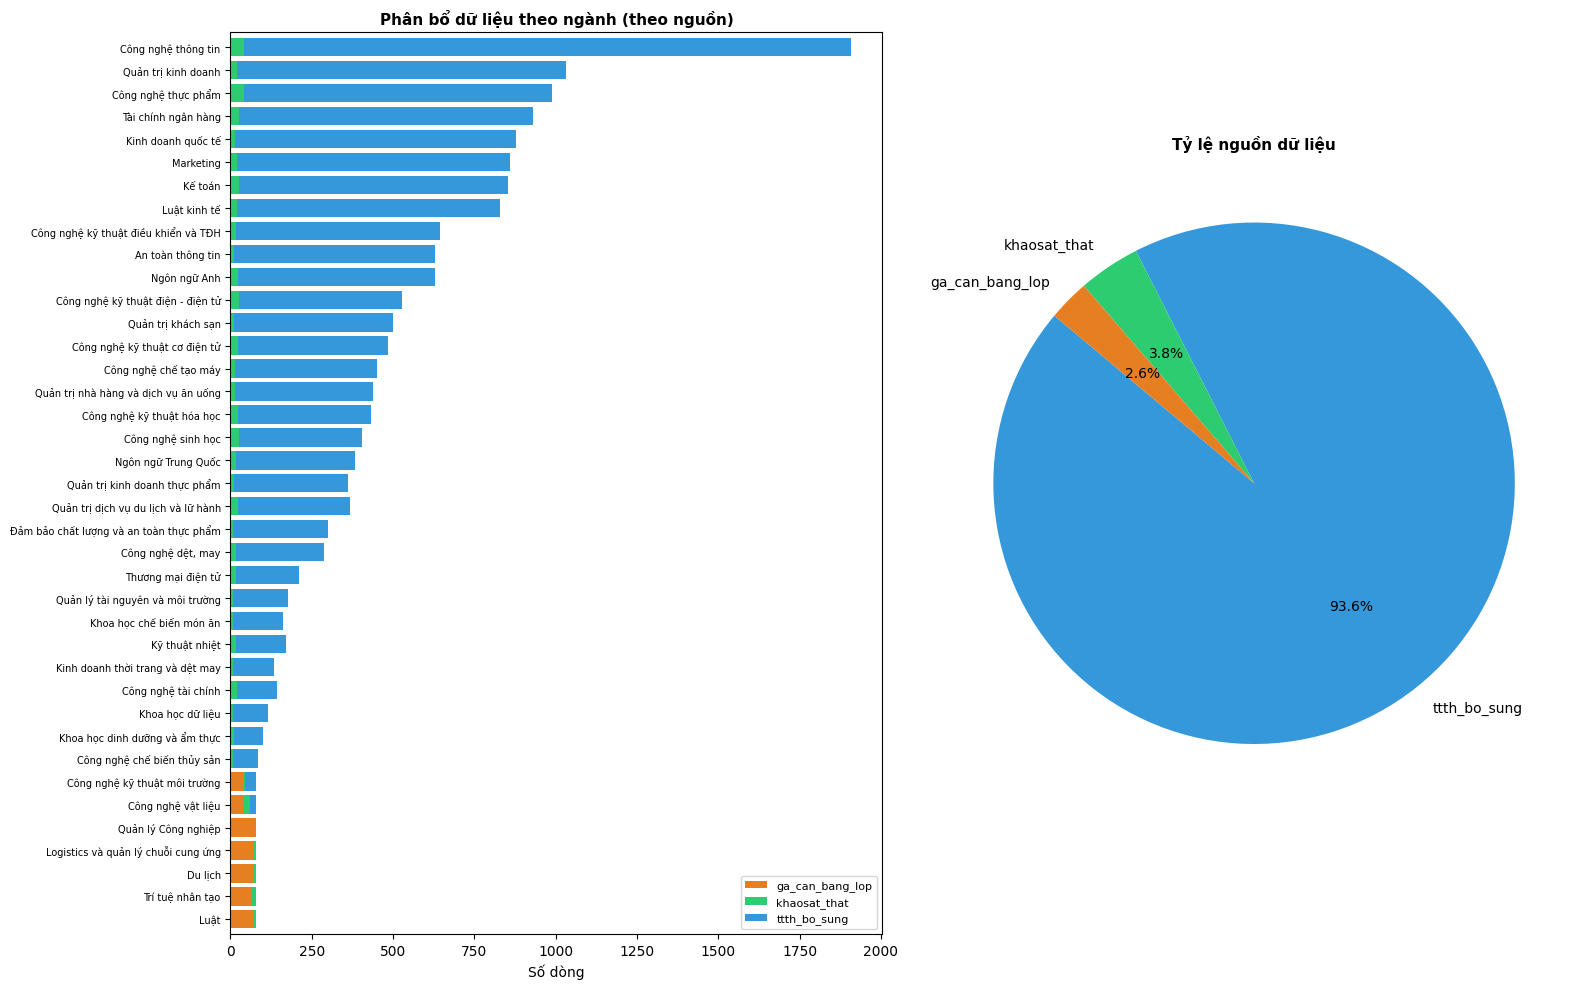

✅ Đã lưu biểu đồ


In [16]:
# ============================================================
# BIỂU ĐỒ — Phân bổ dữ liệu theo ngành và nguồn
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Biểu đồ 1: Stack bar — số dòng mỗi ngành theo nguồn
pivot = (
    df_train_final
    .groupby(["nganh_hoc", "nguon_du_lieu"])
    .size()
    .unstack(fill_value=0)
    .sort_values("ttth_bo_sung" if "ttth_bo_sung" in df_train_final["nguon_du_lieu"].unique() else df_train_final["nguon_du_lieu"].unique()[0])
)

colors = {"khaosat_that": "#2ecc71", "ttth_bo_sung": "#3498db", "ga_can_bang_lop": "#e67e22"}
pivot.plot(kind="barh", stacked=True, ax=axes[0],
           color=[colors.get(c, "#95a5a6") for c in pivot.columns], width=0.8)
axes[0].set_title("Phân bổ dữ liệu theo ngành (theo nguồn)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Số dòng")
axes[0].set_ylabel("")
axes[0].tick_params(axis="y", labelsize=7)
axes[0].legend(fontsize=8, loc="lower right")

# Biểu đồ 2: Pie — tỷ lệ nguồn dữ liệu
counts = df_train_final["nguon_du_lieu"].value_counts()
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=[colors.get(c, "#95a5a6") for c in counts.index],
            startangle=140, textprops={"fontsize": 10})
axes[1].set_title("Tỷ lệ nguồn dữ liệu", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bieu_do_phan_bo_nguon_du_lieu.png", dpi=150)
plt.show()
print("✅ Đã lưu biểu đồ")
